__Woo Pong Py__

Python implementation of the Quantum Woo Pong physics engine. Check out the web game [here](https://tessmero.github.io/woo-pong).

This engine has some special properties
 - Uses only integers
 - Performs only simple math (addition and subtraction)
 - Uses lookup tables to replace complex math
 - Includes seed-based pseudo-random perturbations

The simulation is _deterministic_. It will always evolve in the exact same way as long as we start with the same seed.

We may choose to forcibly reset the seed partway through. Repeating this process with different seeds allows us to develop branching _super-deterministic_ simulations, where multiple possible outcomes are predetermined.

In python, we can leverage powerful tools like scipy.optimize. We use leastSq to fine-tune a closed loop where a disk travels back in time and interacts with its past self. 


**NOTE if you are running this on Google Colab** (as of March 2026)

 - Kernel crashes on first run, then you have to click 'Run all' again
 - You have to move your mouse over the animation to see updates

In [13]:
# required setup and bug work-around for google colab
# fIrst time running: crashes and you have to click "Run all" again
# (https://github.com/googlecolab/colabtools/issues/5425)

# access package in repo
try:
  import woo_pong_py
except ImportError:
  !git clone https://github.com/tessmero/woo-pong-py.git
  !cp -r woo-pong-py/woo_pong_py/ .

# enable interactive figures
try:
  import ipympl
except ImportError:
  !pip install ipympl
  import os
  os.kill(os.getpid(), 9) # end session. user has to click 'Run all' again

try:
    from google.colab import output
    output.enable_custom_widget_manager()
except ImportError:
    pass # not running in google colab
    
%matplotlib widget

In [14]:


from woo_pong_py import DISK_DISK_LUT # pre-computed disk-disk collision lookup table
from woo_pong_py.sim import Simulation
from woo_pong_py.constants import DISK_RADIUS
from woo_pong_py.step import active_step

In [15]:
DISK_DISK_LUT.lut.shape

(21, 21, 41, 41, 4)

In [16]:
# # show animated simulation with 10 colliding disks
# from woo_pong_py.util import sim_pyplot_animation
# sim = Simulation(DISK_DISK_LUT,seed=1234,n_disks=10)
# ani = sim_pyplot_animation(sim)
# ani

**Determinism**

We simulate 10 colliding disks for some time. Then we check the postion of one of the disks. 

If we start over with the same initial conditions, that disk should end up in the same position.

In [17]:

# helper to print the x,y position of the first disk
def report_disk(sim):
    disk = sim.disks[0]
    state = disk.current_state
    return f"{state.x},{state.y}"

# create new simulation
sim = Simulation(DISK_DISK_LUT,seed=1234,n_disks=10)
print(f"initial position: {report_disk(sim)}")

# advance simulation
n_steps = 1000
for i in range(n_steps):
    active_step(sim)
print(f"position after {n_steps} steps:     {report_disk(sim)}")

# rebuild identical simulation to reach the same final position
sim = Simulation(DISK_DISK_LUT,seed=1234,n_disks=10)
for i in range(n_steps):
    active_step(sim)
print(f"restart and re-run {n_steps} steps: {report_disk(sim)}")


initial position: 504831,342593
position after 1000 steps:     662146,497545
restart and re-run 1000 steps: 662146,497545


**Branching**

We start running two identical simulations. After 1000 steps we intervene and give them two different PRNG states. After the branching point they begin to diverge.

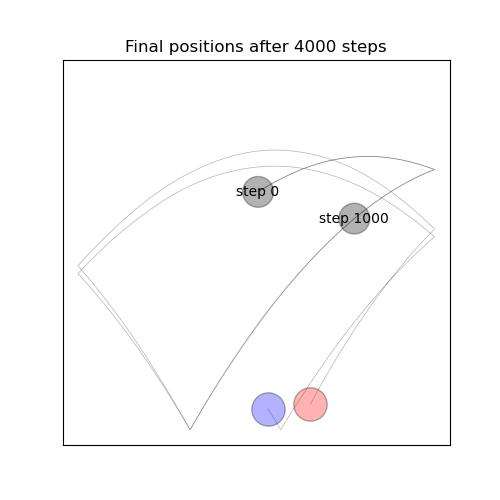

In [18]:
# render simulation using pyplot
from woo_pong_py.util import sim_pyplot

start_seed = 1234 # common starting seed
branch_on_step = 1000
n_disks = 1

# locate position of start and branch points
test_sim = Simulation(DISK_DISK_LUT,seed=start_seed,n_disks=n_disks)
start_x = test_sim.disks[0].current_state.x
start_y = test_sim.disks[0].current_state.y
for i in range(branch_on_step):
    active_step(test_sim)
branch_x = test_sim.disks[0].current_state.x
branch_y = test_sim.disks[0].current_state.y

# build two simulations that will start out identical
red_sim = Simulation(DISK_DISK_LUT,seed=start_seed,n_disks=n_disks)
red_sim.branch_on_step = branch_on_step
red_sim.branch_seed = 1111

blue_sim = Simulation(DISK_DISK_LUT,seed=start_seed,n_disks=n_disks)
blue_sim.branch_on_step = branch_on_step
blue_sim.branch_seed = 2222

# plot the disk paths, starting point and branching point
fig = sim_pyplot(
    [red_sim,blue_sim],
    colors=['red', 'blue'],
    step_count = 4000,
    static_circles=[
        {'x': start_x, 'y': start_y, 'radius': DISK_RADIUS, 'color': 'black', 'alpha': 0.3, 
         'label': f"step 0"},
        {'x': branch_x, 'y': branch_y, 'radius': DISK_RADIUS, 'color': 'black', 'alpha': 0.3, 
         'label': f"step {branch_on_step}"},
    ],
)


**Time Loop**

We want to build a closed time-like loop, where a disk travels into the past and interacts with itself. We create a simulation with one disk, and add a 'spawn event' partway through. At the spawn event, a disk spawns from the time-travel portal at the top of the view.

We start by manually creating a spawn event and hoping it will make sense. We pick a time and trajectory such that the new disk collides with the original disk, sending it into the time-travel portal at the bottom of the view.

In [19]:

from woo_pong_py.util import sim_pyplot_animation, DISK_RADIUS, VALUE_SCALE

sim = Simulation(DISK_DISK_LUT,seed=1234,n_disks=1)

# disk spawns moving to right, collides with future self, enters portal at bottom of view, exits portal in past at top of view
# the portal may offset x-coordinate but should maintain velocity

# params to be optimized
start_dx = 100 # original disk velocity (to the right)
start_dy = 0
spawn_on_step = 1000 # time to spawn time-traveled disk
spawn_dx = 0 # spawned disk velocity (downward)
spawn_dy = 100

# turn off gravity
sim.gravity_x = 0
sim.gravity_y = 0

# set original disk to move from left to right
original_disk = sim.disks[0]
original_disk.current_state.x = DISK_RADIUS
original_disk.current_state.y = 50 * VALUE_SCALE # midpoint on left wall
original_disk.next_state.dx = start_dx
original_disk.next_state.dy = start_dy

# add spawn event
sim.is_loop = True
sim.spawn_on_step = spawn_on_step
sim.spawn_x = 50 * VALUE_SCALE
sim.spawn_y = DISK_RADIUS
sim.spawn_dx = spawn_dx
sim.spawn_dy = spawn_dy

# run sim see if loop connects
for i in range(10000):
    active_step(sim)

    if sim.step_count > 5000 and not sim.has_collided:
        print(f"spawned disk did not collide with original")
        break

    if sim.entered_portal_on_step != -1:
        state = sim.disks[0].current_state
        svel = f"{state.dx},{state.dy}"
        expected = f"{sim.spawn_dx},{sim.spawn_dy}"
        print(f"entered bottom portal on step {sim.entered_portal_on_step} with velocity {svel}. expected velocity: {expected}")
        break

    


entered bottom portal on step 7500 with velocity 145,145. expected velocity: 0,100


**Solving the Loop**

Our 'loop' above is not very convincing because the disk spawns with a different velocity that it has when it enters the portal. In solve-loop.ipynb we use scipy.optimize to find optimized parameters that result in matching velocities.

In this notebook we will skip past the optimization step. Below are previously-optimized values that cause the enter/exit velocities to nearly match.

In [20]:
# ============================================================
# FINAL OPTIMIZATION SUMMARY
# ============================================================
# Optimized Parameters:
#   start_dx=78, start_dy=1
#   spawn_on_step=1051
#   spawn_dx=11, spawn_dy=117
# Velocity Error: [-1, 1]
# Error Magnitude: 1.4
# ============================================================

opt_start_dx=78
opt_start_dy=1
opt_spawn_on_step=1051
opt_spawn_dx=11
opt_spawn_dy=117

**Visualizing the Loop**

To visualize the solved time-travel journey, we center the view on the original disk. When it reaches the portal we rewind the simulation and switch focus to the spawned disk. From this perspective we can verify that our disk appears to move continuously while crossing the portal and going back in time.

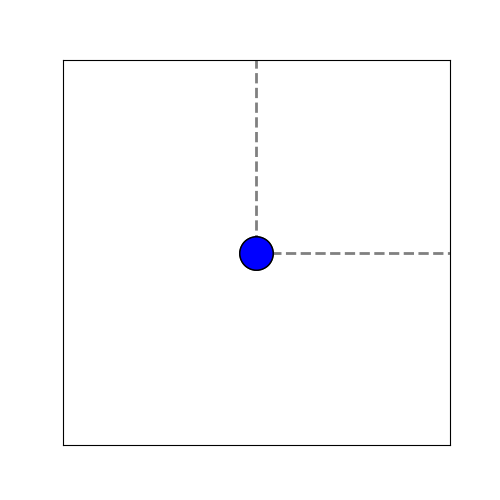

In [21]:


# Create simulation with optimized parameters
def buildSim():
    sim = Simulation(DISK_DISK_LUT, seed=1234, n_disks=1)

    # turn off gravity
    sim.gravity_x = 0
    sim.gravity_y = 0

    # set initial state for original disk
    original_disk = sim.disks[0]
    original_disk.current_state.x = DISK_RADIUS
    original_disk.current_state.y = 50 * VALUE_SCALE
    original_disk.next_state.dx = opt_start_dx
    original_disk.next_state.dy = opt_start_dy

    # schedule spawn event
    sim.is_loop = True
    sim.spawn_on_step = opt_spawn_on_step
    sim.spawn_x = 50 * VALUE_SCALE
    sim.spawn_y = DISK_RADIUS
    sim.spawn_dx = opt_spawn_dx
    sim.spawn_dy = opt_spawn_dy

    return sim


from woo_pong_py.util import sim_loop_pyplot_animation

# Animate the optimized loop
ani_optimized = sim_loop_pyplot_animation(
    buildSim(),buildSim(), # loop animation requires two copies of the sim
    colors=['blue','blue'],
    steps_per_frame=100,
    step_limit = 20_000,
)
ani_optimized